# Adaptive inference at the edge
## Part 1 — The static vision transformer (DeiT-Tiny) baseline

**Task:** 45-class classification of overhead remote sensing images from NWPU-RESISC45.  
**Scope of this notebook:** fine-tune, validate, profile, and preserve **one static transformer**.  

The static baseline processes every image through all 12 transformer blocks. Later, a separate copy will become the adaptive model, and this baseline will remain unchanged as the reference and frozen teacher.

### Requirements of the assignment:

We require a defined edge scenario, compression plus adaptivity, at least three operating points, and an accuracy–FLOPs comparison. We **fix the baseline before building the adaptive system**, use one consistent cost-counting methodology, and keep policy selection separate from final evaluation [C1, §§5–6, 9]. Part 1 completes the baseline stage.

The deployment scenario is a resource-constrained field gateway classifying incoming image tiles for local indexing. RESISC45 is a benchmark for this scenario, not a recorded stream from that gateway. Images are independent; we are not performing temporal change detection.

### Running this notebook:

Here we use a Python **3.12 or 3.13** Jupyter kernel.

The RESISC45 images are downloaded manually from the source linked in Part B.1 and extracted to `data/NWPU-RESISC45/`. The notebook loads the local images; it does not download or extract the image archive. The three small published split manifests are downloaded automatically if missing. Pretrained weights are fetched on their first use (approximately 23 MB); a local weight-file option is provided for offline compute nodes.

`RUN_MODE = "full"` trains the baseline. `RUN_MODE = "smoke"` runs a one-epoch, small-subset pipeline check in a separately named output folder and this one isn't frozen as the reference of course. Neither mode evaluates the test set.

Experimental results. We evaluate the baseline using classification accuracy, computational cost (FLOPs), and inference latency. All reported measurements are generated directly from model execution on RESISC45. We want to see how it performs.


## 1A — Environment and experiment settings

### Reproducible environment

All dependencies are listed in the repository's `requirements.txt`. We install them **once in the selected Python environment**, outside the notebook:

```bash
python -m pip install -r requirements.txt
```

After installation, select that environment as the Jupyter kernel. No package installation or machine-specific paths are hidden in subsequent cells. Our reference environment targets Python 3.12/3.13; the selected machine and installed package versions are recorded with each experiment. [R4–R7]


In [1]:
# importing the baseline dependencies
import copy
import hashlib
import json
import math
import os
import platform
import random
import shutil
import sys
import time
import warnings
from contextlib import nullcontext
from importlib.metadata import version
from pathlib import Path, PurePosixPath
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision
import timm
from PIL import Image
from IPython.display import display
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm
from timm.data import resolve_model_data_config
from fvcore.nn import FlopCountAnalysis
from fvcore.nn.jit_handles import get_shape

if sys.version_info[:2] not in {(3, 12), (3, 13)}:
    raise RuntimeError("Select a Python 3.12 or 3.13 Jupyter kernel.")
versions = {name: version(name) for name in (
    "torch", "torchvision", "timm", "fvcore", "numpy", "pandas", "matplotlib", "Pillow", "tqdm"
)}
display(pd.Series(versions, name="version").to_frame())


/Users/waronig/Developer/adaptive-inference-edge/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,version
torch,2.10.0
torchvision,0.25.0
timm,1.0.21
fvcore,0.1.5.post20221221
numpy,2.5.3
pandas,2.3.3
matplotlib,3.11.2
Pillow,12.3.0
tqdm,4.70.1


###  One settings cell

All machine-dependent paths and principal experimental choices appear here. **Run the notebook from the repository root**, which contains `requirements.txt`. This convention is intentionally simpler than trying to infer the location of a notebook from Jupyter internals. The runtime checks it before downloading data or training.

The first run should use `RUN_MODE = "smoke"`; this fine-tunes on a small subset for one epoch to verify the complete pipeline. The full run uses 30 epochs and the published training split. The learning rates and epoch count are starting choices, not results of hyperparameter optimisation.

When changing model/training settings after a run has begun, choose a new `RUN_NAME`. Resume an existing run only with its original experimental settings. Hardware and absolute filesystem paths are not part of the experiment identity.


In [2]:
# configuring paths and experiment settings
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "runs"
RUN_NAME = "baseline_deit_tiny_seed42"
RUN_MODE = "full"                             # choosing "smoke" before "full"
LOCAL_PRETRAINED_WEIGHTS = None                # using a local official weight file when offline

DEVICE = "auto"                                # choosing "auto", "mps", "cuda", or "cpu"
BATCH_SIZE = 32
EPOCHS = 30
BACKBONE_LR = 1e-4
HEAD_LR = 5e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 3
MIN_LR_RATIO = 0.01
GRAD_CLIP_NORM = 1.0
NUM_WORKERS = 0                               # keeping notebook-defined datasets portable
SEED = 42
SPLIT_SEED = 2026

BENCHMARK_DEVICE = "cpu"                       # measuring comparable batch-one CPU latency
BENCHMARK_THREADS = 1
BENCHMARK_WARMUP = 20
BENCHMARK_REPEATS = 100

MODEL_NAME = "deit_tiny_patch16_224.fb_in1k"
IMAGE_SIZE = 224
NUM_CLASSES = 45

if not (PROJECT_ROOT / "requirements.txt").is_file():
    raise RuntimeError(
        f"Working directory is {PROJECT_ROOT}. Run the notebook from the repository root "
        "(the directory containing requirements.txt)."
    )
if RUN_MODE not in {"smoke", "full"}:
    raise ValueError("RUN_MODE must be 'smoke' or 'full'.")
if Path(RUN_NAME).name != RUN_NAME or RUN_NAME in {"", ".", ".."}:
    raise ValueError("RUN_NAME must be a single directory name.")
if EPOCHS < 1 or BATCH_SIZE < 1 or NUM_WORKERS < 0:
    raise ValueError("EPOCHS and BATCH_SIZE must be positive; NUM_WORKERS cannot be negative.")
if RUN_MODE == "full" and not 0 <= WARMUP_EPOCHS < EPOCHS:
    raise ValueError("Require 0 <= WARMUP_EPOCHS < EPOCHS.")
if NUM_WORKERS and platform.system() in {"Darwin", "Windows"}:
    raise ValueError("Use NUM_WORKERS = 0 in a self-contained macOS/Windows notebook.")

RUN_DIR = OUTPUT_DIR / (RUN_NAME + ("_smoke" if RUN_MODE == "smoke" else ""))
TOTAL_EPOCHS = 1 if RUN_MODE == "smoke" else EPOCHS
EFFECTIVE_WARMUP = 0 if RUN_MODE == "smoke" else WARMUP_EPOCHS
DATA_DIR.mkdir(exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Repository:", PROJECT_ROOT)
print("Dataset:", DATA_DIR)
print("Run:", RUN_DIR)


Repository: /Users/waronig/Developer/adaptive-inference-edge
Dataset: /Users/waronig/Developer/adaptive-inference-edge/data
Run: /Users/waronig/Developer/adaptive-inference-edge/runs/baseline_deit_tiny_seed42


In [3]:
# selecting the accelerator and controlling randomness
def select_device(name: str) -> torch.device:
    if name == "auto":
        name = "cuda" if torch.cuda.is_available() else (
            "mps" if torch.backends.mps.is_available() else "cpu"
        )
    if name == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA is unavailable in the selected Python environment.")
    if name == "mps" and not torch.backends.mps.is_available():
        raise RuntimeError("Apple MPS is unavailable in the selected Python environment.")
    if name not in {"cpu", "mps", "cuda"}:
        raise ValueError("Select auto, cpu, mps, or cuda.")
    return torch.device(name)


def seed_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def sync(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps":
        torch.mps.synchronize()


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def save_checkpoint(payload: dict, path: Path) -> None:
    temporary = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)


TRAIN_DEVICE = select_device(DEVICE)
seed_all(SEED)
AMP_ENABLED = TRAIN_DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if AMP_ENABLED and torch.cuda.is_bf16_supported() else torch.float16

def train_autocast():
    return torch.autocast("cuda", dtype=AMP_DTYPE) if AMP_ENABLED else nullcontext()

environment = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "device": str(TRAIN_DEVICE),
    "packages": versions,
    "train_precision": str(AMP_DTYPE) if AMP_ENABLED else "float32",
}
print("Training on:", TRAIN_DEVICE, "| precision:", environment["train_precision"])


Training on: mps | precision: float32


## 1B — Dataset and evaluation protocol

### Obtaining and inspecting RESISC45

NWPU-RESISC45 contains **31,500 images of 256 × 256 pixels**, organised into **45 scene categories with 700 images each** [R1]. For this experiment, we obtain the image archive separately and keep the original filenames and directory structure.

**Dataset sources:**

- **Original publication:** [Cheng, Han, and Lu (2017)](https://doi.org/10.1109/JPROC.2017.2675998), with the [authors' dataset page](https://gcheng-nwpu.github.io/).
- **Image archive used for reproduction:** [Download NWPU-RESISC45.zip (pinned Hugging Face mirror)](https://huggingface.co/datasets/isaaccorley/resisc45/resolve/883edc0eee77b2c84225472f10f126e3ed83fa6e/NWPU-RESISC45.zip) [R2].

Download and extract the ZIP once, then place this extracted `NWPU-RESISC45` folder under the repository's `data/` folder:

```text
adaptive-inference-edge/
├── static_vit_baseline.ipynb
├── requirements.txt
└── data/
    └── NWPU-RESISC45/
        ├── airplane/
        │   ├── airplane_001.jpg
        │   └── ...
        ├── airport/
        └── ... (45 classes in total)
```



Dataset: 45 classes, 31,500 images


,class,images
0,airplane,700
1,airport,700
2,baseball_diamond,700
3,basketball_court,700
4,beach,700
5,bridge,700
6,chaparral,700
7,church,700
8,circular_farmland,700
9,cloud,700


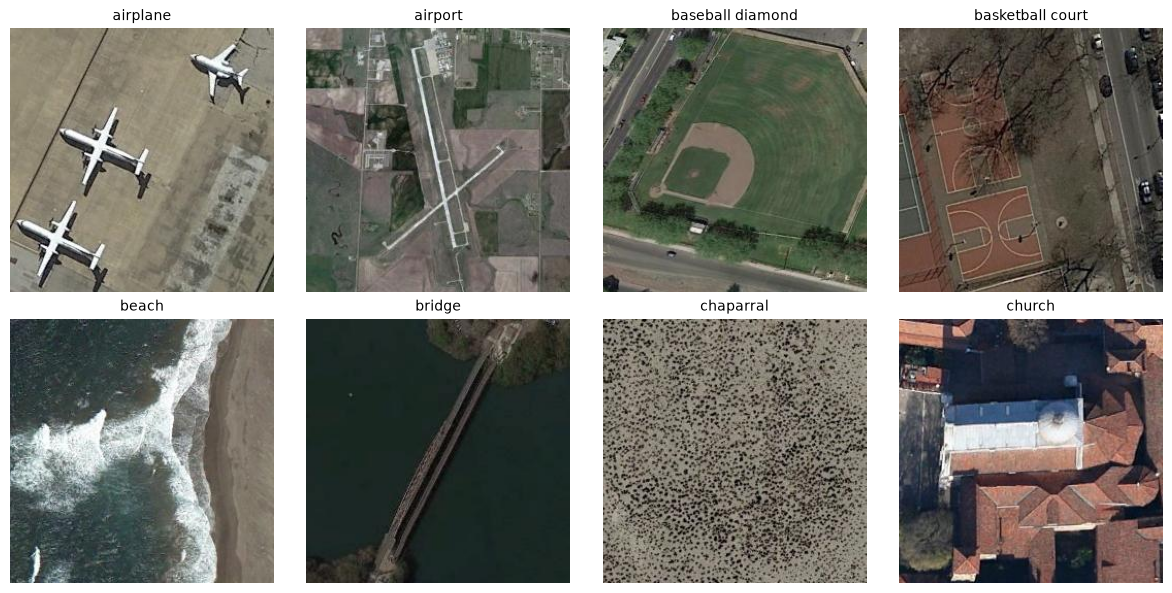

In [4]:
# inspecting the locally extracted images
IMAGE_ROOT = DATA_DIR / "NWPU-RESISC45"
if not IMAGE_ROOT.is_dir():
    raise FileNotFoundError(
        f"Missing {IMAGE_ROOT}. Download and extract the archive as described above."
    )

class_folders = sorted(folder for folder in IMAGE_ROOT.iterdir() if folder.is_dir() and not folder.name.startswith("."))
counts = pd.DataFrame([
    {"class": folder.name, "images": sum(file.suffix.lower() in {".jpg", ".jpeg"} for file in folder.iterdir())}
    for folder in class_folders
])
print(f"Dataset: {len(counts)} classes, {counts['images'].sum():,} images")
display(counts)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, folder in zip(axes.flat, class_folders[:8]):
    example = next(iter(sorted(folder.glob("*.jpg"))))
    with Image.open(example) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(folder.name.replace("_", " "), fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


### Published splits and leakage prevention

To compare the static and adaptive models fairly, we retain the **published Google Research split definitions** [R3]: 18,900 training, 6,300 validation, and 6,300 test images. The three small filename manifests are obtained automatically from [Google Research](https://github.com/google-research/google-research/tree/master/remote_sensing_representations) if they are not already present in `data/splits/`. Their checksums are verified so the experimental partitions cannot silently change.

We further divide the published validation set into `val_select` (choosing the static checkpoint) and `val_policy` (reserved for later adaptive confidence calibration). The held-out test images remain unused at this stage. The manifest is saved alongside each run, allowing collaborators to reproduce the same partition without publishing the images themselves.


In [5]:
# obtaining the three small published split files when missing
SPLIT_DIR = DATA_DIR / "splits"
SPLIT_DIR.mkdir(exist_ok=True)
SPLIT_SHA256 = {
    "train": "ecfa963be4d85eac83665f8be8634abcb4fe6f3546472cc0e87999e2cab4449b",
    "val": "08d81f642526bec240589000af7f49a47e8d071a6e7925b0f36246a78ab64342",
    "test": "e0927e80130b47317a2f18520d98382b6fc56f0d3edd3345140f7d02267c3805",
}
for split, expected_hash in SPLIT_SHA256.items():
    path = SPLIT_DIR / f"resisc45-{split}.txt"
    if not path.exists():
        url = (
    "https://huggingface.co/datasets/isaaccorley/resisc45/resolve/"
    f"883edc0eee77b2c84225472f10f126e3ed83fa6e/resisc45-{split}.txt"
)
        urlretrieve(url, path)
    if file_sha256(path) != expected_hash:
        raise ValueError(f"Unexpected contents in {path}; check the published split source.")

# indexing image filenames and reproducing the published split
class_names = sorted(p.name for p in IMAGE_ROOT.iterdir() if p.is_dir() and not p.name.startswith("."))
if len(class_names) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} class directories, found {len(class_names)}.")
class_to_idx = {name: i for i, name in enumerate(class_names)}
index = {}
for name in class_names:
    image_files = sorted(p for p in (IMAGE_ROOT / name).iterdir() if p.suffix.lower() in {".jpg", ".jpeg"})
    if len(image_files) != 700:
        raise ValueError(f"Expected 700 images for '{name}', found {len(image_files)}.")
    for path in image_files:
        if path.name in index:
            raise ValueError(f"Duplicate image filename: {path.name}")
        index[path.name] = (path.relative_to(IMAGE_ROOT).as_posix(), class_to_idx[name])


def read_split(name: str) -> pd.DataFrame:
    lines = (SPLIT_DIR / f"resisc45-{name}.txt").read_text(encoding="utf-8-sig").splitlines()
    filenames = [PurePosixPath(line.strip().replace("\\", "/")).name for line in lines if line.strip()]
    if len(filenames) != len(set(filenames)) or not set(filenames) <= index.keys():
        raise ValueError(f"Invalid filenames in published {name} split.")
    rows = [(file, index[file][0], index[file][1], name) for file in filenames]
    return pd.DataFrame(rows, columns=["filename", "relative_path", "label", "split"]).sort_values("filename").reset_index(drop=True)


published = {name: read_split(name) for name in ("train", "val", "test")}
for name, expected in (("train", 18900), ("val", 6300), ("test", 6300)):
    if len(published[name]) != expected:
        raise ValueError(f"Unexpected published {name} size: {len(published[name])}.")
if (pd.concat(published.values()).filename.duplicated().any()
        or set(pd.concat(published.values()).filename) != set(index)):
    raise ValueError("Published splits overlap or do not cover the dataset.")


def partition_validation(frame: pd.DataFrame, seed: int):
    rng = np.random.default_rng(seed)
    groups = frame.groupby("label", sort=True)
    sizes = groups.size()
    counts = (sizes // 2).copy()
    remainder = len(frame) // 2 - int(counts.sum())
    odd = sizes.index[sizes % 2 == 1].to_numpy()
    for label in rng.permutation(odd)[:remainder]:
        counts.loc[label] += 1
    selected, reserved = [], []
    for label, group in groups:
        permuted = rng.permutation(group.index.to_numpy())
        cut = int(counts.loc[label])
        selected.extend(permuted[:cut])
        reserved.extend(permuted[cut:])
    select = frame.loc[selected].copy().assign(split="val_select").sort_values("filename").reset_index(drop=True)
    policy = frame.loc[reserved].copy().assign(split="val_policy").sort_values("filename").reset_index(drop=True)
    return select, policy


train_frame = published["train"]
select_frame, policy_frame = partition_validation(published["val"], SPLIT_SEED)
test_frame = published["test"]
assert len(select_frame) == len(policy_frame) == 3150
manifest = pd.concat((train_frame, select_frame, policy_frame, test_frame), ignore_index=True)
manifest_path = RUN_DIR / "split_manifest.csv"
manifest_csv = manifest.to_csv(index=False, lineterminator="\n")
if manifest_path.exists() and manifest_path.read_text() != manifest_csv:
    raise RuntimeError("Existing split manifest differs. Choose a new RUN_NAME.")
manifest_path.write_text(manifest_csv)
(RUN_DIR / "class_to_idx.json").write_text(json.dumps(class_to_idx, indent=2, sort_keys=True))
manifest_sha256 = hashlib.sha256(manifest_csv.encode()).hexdigest()
display(manifest.groupby("split").size().rename("images").to_frame())


,images
split,
test,6300
train,18900
val_policy,3150
val_select,3150


## 1C — The static model and its computational cost

### DeiT-Tiny and preprocessing

We use the **non-distilled-token** DeiT-Tiny checkpoint `deit_tiny_patch16_224.fb_in1k` [R8–R9]. The $224\times224$ input is converted into $14\times14=196$ image patches plus a class token. Its twelve transformer blocks use 192-dimensional embeddings. A new classifier produces 45 scene scores.

The source images are **$256\times256$ pixels**, whereas the pretrained checkpoint expects **$224\times224$ pixels**. With $16\times16$ patches, this gives $14\times14=196$ spatial tokens (plus the class token) and matches the checkpoint's learned positional-embedding layout. Each entire image is resized with bicubic interpolation and antialiasing rather than center-cropped, so no scene region is intentionally discarded; however, some fine detail can be lost through downsampling. Using $256\times256$ would require positional-embedding interpolation and additional computation, and is outside our initial fixed-input comparison. ImageNet mean and standard deviation are obtained from the pretrained checkpoint. Training includes right-angle rotations and horizontal/vertical flips; validation uses deterministic preprocessing. Every image in the static model executes all twelve transformer blocks.


In [6]:
# loading the pretrained model or reconstructing an existing checkpoint
BEST_PATH = RUN_DIR / "best.pt"
LAST_PATH = RUN_DIR / "last.pt"
if BEST_PATH.exists() and not LAST_PATH.exists():
    raise RuntimeError("best.pt exists without last.pt. Inspect the run before continuing.")

model_options = {"num_classes": NUM_CLASSES, "drop_path_rate": 0.0}
if LOCAL_PRETRAINED_WEIGHTS and not LAST_PATH.exists():
    weights = Path(LOCAL_PRETRAINED_WEIGHTS).expanduser().resolve()
    if not weights.is_file():
        raise FileNotFoundError(weights)
    model_options["pretrained_cfg_overlay"] = {"file": str(weights)}
model = timm.create_model(MODEL_NAME, pretrained=not LAST_PATH.exists(), **model_options)
mean_std = resolve_model_data_config(model)
mean, std = mean_std["mean"], mean_std["std"]
assert len(model.blocks) == 12 and model.num_features == 192
assert tuple(model.patch_embed.patch_size) == (16, 16)
assert model.get_classifier().out_features == NUM_CLASSES
print("Model:", MODEL_NAME, "| parameters:", f"{sum(p.numel() for p in model.parameters()):,}")


Model: deit_tiny_patch16_224.fb_in1k | parameters: 5,533,101


In [7]:
# preparing image transformations
class RandomQuarterTurn:
    def __call__(self, image):
        return image.rotate(90 * random.randrange(4))


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BICUBIC),
    RandomQuarterTurn(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


# defining the dataset
class SceneDataset(Dataset):
    def __init__(self, rows, transform):
        self.rows = rows.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows.iloc[index]

        with Image.open(IMAGE_ROOT / row.relative_path) as image:
            image = self.transform(image.convert("RGB"))

        return image, int(row.label)


# creating batches for training and evaluation
def make_loader(dataset, shuffle=False, epoch=0):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        generator=torch.Generator().manual_seed(SEED + epoch),
    )


# selecting a small subset for the smoke test
if RUN_MODE == "smoke":
    active_train = train_frame.groupby("label").sample(n=8, random_state=SEED)
    active_select = select_frame.groupby("label").sample(n=2, random_state=SEED)
else:
    active_train = train_frame
    active_select = select_frame


# constructing the training and validation datasets
train_dataset = SceneDataset(active_train, train_transform)
select_dataset = SceneDataset(active_select, eval_transform)
select_loader = make_loader(select_dataset)

example_images, example_labels = next(iter(make_loader(train_dataset)))

assert example_images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(select_dataset)}")
print(f"Batch shape: {tuple(example_images.shape)}")

Training images: 18900
Validation images: 3150
Batch shape: (32, 3, 224, 224)


### Measuring FLOPs consistently

Our comparisons are grounded in **accuracy versus executed FLOPs**. Our counter uses `fvcore`, whose convention counts one fused multiply-add as one FLOP [R10]. For transparency, a **temporary CPU copy** exposes attention operations that a fused attention kernel might hide from tracing. The ordinary model implementation is still used for training and latency measurements.

We also count common elementwise operations, softmax and GELU using explicitly documented scalar-operation conventions. These approximate arithmetic counts are **not** energy measurements. The same counter and operator rules must be reused later for every early-exit path, including the cost of intermediate heads and the controller.


In [8]:
# defining the FLOPs counting convention
FLOPS_CONVENTION = {
    "version": "fvcore_fma1_scalar_v1",
    "multiply_add": "1 FLOP per multiply-add",
    "attention": "explicit attention",
    "scalar_operations": "approximate counts",
}


def profile_flops(model, images):
    # copying the model to avoid modifying the training model
    probe = copy.deepcopy(model).cpu().float().eval()
    x = images[:1].cpu().float()

    # checking that explicit attention preserves the model output
    with torch.inference_mode():
        original = probe(x)

        for block in probe.blocks:
            block.attn.fused_attn = False

        explicit = probe(x)

    torch.testing.assert_close(original, explicit, rtol=1e-3, atol=1e-4)

    # counting scalar operations omitted by the default profiler
    def elements(value):
        return math.prod(get_shape(value))

    def elementwise(inputs, outputs):
        return elements(outputs[0])

    def gelu(inputs, outputs):
        approximation = inputs[1].toIValue() if len(inputs) > 1 else "none"
        return (9 if approximation == "tanh" else 5) * elements(inputs[0])

    counter = FlopCountAnalysis(probe, x)
    counter.tracer_warnings("none")
    counter.unsupported_ops_warnings(False)

    for op in ("add", "sub", "mul", "div"):
        counter.set_op_handle(f"aten::{op}", elementwise)

    counter.set_op_handle("aten::softmax",
                          lambda inputs, outputs: 4 * elements(inputs[0]))
    counter.set_op_handle("aten::gelu", gelu)

    for op in ("mean", "sum"):
        counter.set_op_handle(
            f"aten::{op}",
            lambda inputs, outputs: elements(inputs[0])
        )

    flops = float(counter.total())
    unsupported = dict(counter.unsupported_ops())

    if unsupported or flops <= 0:
        raise RuntimeError(f"Incomplete FLOPs count: {unsupported}")

    return {
        "parameters": sum(p.numel() for p in probe.parameters()),
        "flops_per_image": flops,
        "gflops_per_image": flops / 1e9,
        "by_operator": dict(counter.by_operator()),
        "attention_max_difference": float((original - explicit).abs().max()),
        "convention": FLOPS_CONVENTION,
    }


# profiling the static baseline
flops_profile = profile_flops(model, example_images)

(RUN_DIR / "flops.json").write_text(json.dumps(flops_profile, indent=2))
# displaying the baseline computational profile
display(pd.DataFrame({
    "Parameters": [f"{flops_profile['parameters']:,}"],
    "GFLOPs / image": [f"{flops_profile['gflops_per_image']:.3f}"],
}, index=["DeiT-Tiny"]))

,Parameters,GFLOPs / image
DeiT-Tiny,"5,533,101",1.274


## 1D — Fine-tuning the static baseline

### Supervised objective and learning-rate schedule

For a minibatch of $B$ images and labels, training minimises the ordinary cross-entropy:

$$\mathcal{L}(\theta) = -\frac{1}{B}\sum_{i=1}^{B}\log p_{\theta}(y_i\mid x_i).$$

The entire pretrained transformer is trainable. AdamW assigns a lower learning rate to the backbone and a higher one to the new classifier, with weight decay disabled for biases and normalization parameters. Learning rates warm up linearly and then decay according to a cosine schedule. No pruning, quantization, auxiliary classifiers, or knowledge distillation is introduced in this stage.

Each completed epoch produces `last.pt`, which includes optimizer state and can resume training. The highest `val_select` accuracy determines `best.pt` (cross-entropy breaks ties). Randomness is reseeded at epoch boundaries, making resumption straightforward; bitwise agreement between different hardware backends is not guaranteed [R5].


We fine-tune the pretrained DeiT-Tiny using AdamW and cross-entropy loss. A lower learning rate is assigned to the pretrained transformer, while the newly initialised classification head receives a higher learning rate. Linear warm-up and cosine decay control the learning rate throughout training.
The experiment configuration is saved alongside the checkpoints to ensure that interrupted training can be resumed consistently.

In [9]:
# recording the experiment configuration for reproducibility
run_config = {
    "model": MODEL_NAME,
    "run_mode": RUN_MODE,
    "epochs": TOTAL_EPOCHS,
    "batch_size": BATCH_SIZE,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "warmup_epochs": EFFECTIVE_WARMUP,
    "min_lr_ratio": MIN_LR_RATIO,
    "gradient_clip_norm": GRAD_CLIP_NORM,
    "seed": SEED,
    "split_seed": SPLIT_SEED,
    "split_manifest_sha256": manifest_sha256,
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "mean": list(mean),
    "std": list(std),
    "augmentation": "random quarter turn, horizontal flip, vertical flip",
    "training_samples": len(train_dataset),
    "selection_samples": len(select_dataset),
}
config_path = RUN_DIR / "run_config.json"
if config_path.exists() and json.loads(config_path.read_text()) != run_config:
    raise RuntimeError("Experiment settings differ from the existing run. Choose a new RUN_NAME.")
config_path.write_text(json.dumps(run_config, indent=2, sort_keys=True))
if not (RUN_DIR / "environment.json").exists():
    (RUN_DIR / "environment.json").write_text(json.dumps(environment, indent=2))


def build_optimizer(network):
    no_decay = network.no_weight_decay() if hasattr(network, "no_weight_decay") else set()
    groups = {}
    for name, parameter in network.named_parameters():
        if not parameter.requires_grad:
            continue
        is_head = name.startswith("head.")
        decay = 0.0 if parameter.ndim <= 1 or name in no_decay else WEIGHT_DECAY
        groups.setdefault((is_head, decay), []).append(parameter)
    return torch.optim.AdamW([
        {"params": params, "lr": HEAD_LR if is_head else BACKBONE_LR,
         "base_lr": HEAD_LR if is_head else BACKBONE_LR, "weight_decay": decay}
        for (is_head, decay), params in groups.items()
    ])


def lr_multiplier(epoch):
    if epoch < EFFECTIVE_WARMUP:
        return (epoch + 1) / EFFECTIVE_WARMUP
    progress = (epoch - EFFECTIVE_WARMUP) / max(1, TOTAL_EPOCHS - EFFECTIVE_WARMUP - 1)
    return MIN_LR_RATIO + 0.5 * (1 - MIN_LR_RATIO) * (1 + math.cos(math.pi * progress))


model = model.to(TRAIN_DEVICE)
optimizer = build_optimizer(model)
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED and AMP_DTYPE == torch.float16)


In [10]:
# training the model for one epoch
def train_one_epoch(network, loader):
    network.train()

    total_loss = torch.zeros((), device=TRAIN_DEVICE)
    total_correct = torch.zeros((), device=TRAIN_DEVICE)
    total_images = 0

    sync(TRAIN_DEVICE)
    start = time.perf_counter()

    for images, labels in tqdm(loader, desc="training", leave=False):
        images = images.to(TRAIN_DEVICE)
        labels = labels.to(TRAIN_DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with train_autocast():
            logits = network(images)
            loss = F.cross_entropy(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(network.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.detach().float() * labels.size(0)
        total_correct += (logits.detach().argmax(1) == labels).sum()
        total_images += labels.size(0)

    sync(TRAIN_DEVICE)

    return {
        "train_loss": (total_loss / total_images).item(),
        "train_accuracy_pct": 100 * (total_correct / total_images).item(),
        "train_seconds": time.perf_counter() - start,
    }


# evaluating the model without updating its weights
@torch.inference_mode()
def evaluate(network, loader, collect=False):
    network.eval()

    total_loss = torch.zeros((), device=TRAIN_DEVICE)
    total_correct = torch.zeros((), device=TRAIN_DEVICE)
    total_images = 0
    logits_all, labels_all = [], []

    for images, labels in tqdm(loader, desc="validation", leave=False):
        images = images.to(TRAIN_DEVICE)
        labels = labels.to(TRAIN_DEVICE)

        logits = network(images).float()

        total_loss += F.cross_entropy(logits, labels, reduction="sum")
        total_correct += (logits.argmax(1) == labels).sum()
        total_images += labels.size(0)

        if collect:
            logits_all.append(logits.cpu())
            labels_all.append(labels.cpu())

    metrics = {
        "val_loss": (total_loss / total_images).item(),
        "val_accuracy_pct": 100 * (total_correct / total_images).item(),
    }

    if collect:
        return metrics, torch.cat(logits_all), torch.cat(labels_all)

    return metrics

### Launching or resuming training

A smoke run uses **8 training and 2 selection-validation images per class for one epoch**. It checks the entire data-to-checkpoint pipeline but does not provide meaningful accuracy. The full run uses **all 18,900 training images and 3,150 selection-validation images** for the configured number of epochs.

An interrupted run resumes from the last completed epoch if the run settings match. `best.pt` is kept separately from the resumable `last.pt`. The test and policy-validation images are never passed to the data loaders.


In [11]:
# training the selected model and preserving the best checkpoint
history = []
start_epoch = 0
best_accuracy, best_loss = -1.0, float("inf")
if LAST_PATH.exists():
    saved = torch.load(LAST_PATH, map_location="cpu", weights_only=True)
    if saved["run_config"] != run_config:
        raise RuntimeError("Saved checkpoint configuration does not match this run.")
    model.load_state_dict(saved["model_state"])
    optimizer.load_state_dict(saved["optimizer_state"])
    if saved.get("scaler_state") and scaler.is_enabled():
        scaler.load_state_dict(saved["scaler_state"])
    history = saved["history"]
    start_epoch = saved["epoch"]
    best_accuracy, best_loss = saved["best_accuracy"], saved["best_loss"]
    print(f"Resuming from completed epoch {start_epoch}.")

for epoch in range(start_epoch, TOTAL_EPOCHS):
    seed_all(SEED + epoch)
    factor = lr_multiplier(epoch)
    for group in optimizer.param_groups:
        group["lr"] = group["base_lr"] * factor
    train_metrics = train_one_epoch(model, make_loader(train_dataset, shuffle=True, epoch=epoch))
    val_metrics = evaluate(model, select_loader)
    if not all(math.isfinite(value) for value in (train_metrics["train_loss"], val_metrics["val_loss"])):
        raise FloatingPointError("Non-finite epoch metrics. Inspect the run before continuing.")
    improved = (val_metrics["val_accuracy_pct"] > best_accuracy or
                (val_metrics["val_accuracy_pct"] == best_accuracy and val_metrics["val_loss"] < best_loss))
    if improved:
        best_accuracy, best_loss = val_metrics["val_accuracy_pct"], val_metrics["val_loss"]
        save_checkpoint({
            "epoch": epoch + 1, "model_state": model.state_dict(),
            "run_config": run_config, "class_to_idx": class_to_idx,
            "validation": val_metrics,
        }, BEST_PATH)
    row = {"epoch": epoch + 1, "lr_factor": factor, **train_metrics, **val_metrics}
    history.append(row)
    save_checkpoint({
        "epoch": epoch + 1, "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(), "scaler_state": scaler.state_dict(),
        "history": history, "run_config": run_config,
        "best_accuracy": best_accuracy, "best_loss": best_loss,
    }, LAST_PATH)
    pd.DataFrame(history).to_csv(RUN_DIR / "history.csv", index=False)
    print(f"Epoch {epoch+1:02d}/{TOTAL_EPOCHS}: "
          f"train {train_metrics['train_accuracy_pct']:.2f}%, "
          f"val {val_metrics['val_accuracy_pct']:.2f}%, "
          f"loss {val_metrics['val_loss']:.4f}, "
          f"time {train_metrics['train_seconds']:.0f}s" + (" [best]" if improved else ""))

if not BEST_PATH.exists():
    raise RuntimeError("Training did not produce a best checkpoint.")
history_df = pd.DataFrame(history)
print(f"Best selection-validation accuracy: {best_accuracy:.2f}%")


Epoch 01/30: train 73.46%, val 87.81%, loss 0.4302, time 51s [best]


Epoch 02/30: train 89.77%, val 89.97%, loss 0.3099, time 50s [best]


Epoch 03/30: train 91.30%, val 90.73%, loss 0.2779, time 50s [best]


Epoch 04/30: train 93.44%, val 91.49%, loss 0.2704, time 50s [best]


Epoch 05/30: train 94.17%, val 92.32%, loss 0.2613, time 50s [best]


...

Epoch 26/30: train 100.00%, val 95.68%, loss 0.2593, time 52s


Epoch 27/30: train 100.00%, val 95.46%, loss 0.2631, time 52s


Epoch 28/30: train 100.00%, val 95.59%, loss 0.2638, time 58s


Epoch 29/30: train 99.99%, val 95.65%, loss 0.2635, time 61s


Epoch 30/30: train 100.00%, val 95.56%, loss 0.2640, time 59s
Best selection-validation accuracy: 95.81%


### Learning curves

Training and selection-validation loss/accuracy reveal whether optimisation converges, generalisation deteriorates, or the epoch budget is insufficient. These are *development diagnostics*; no test-set performance is claimed at this stage.


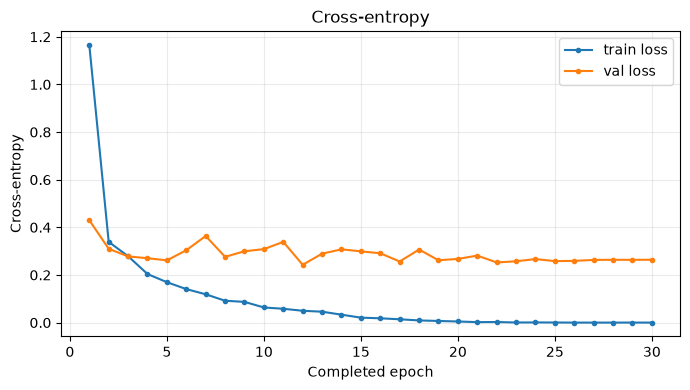

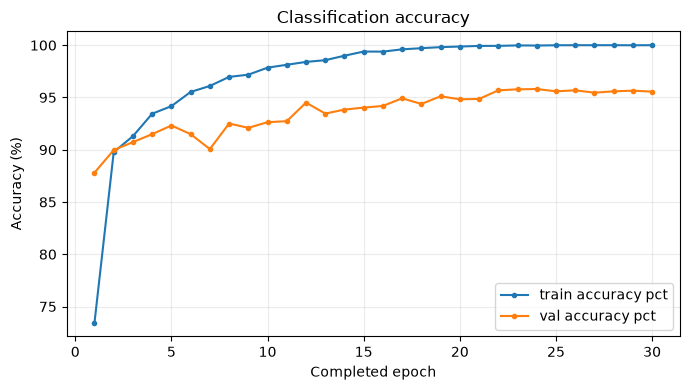

In [12]:
# plotting the observed learning curves
FIGURES = RUN_DIR / "figures"
FIGURES.mkdir(exist_ok=True)
for title, y_columns, ylabel, filename in (
    ("Cross-entropy", ("train_loss", "val_loss"), "Cross-entropy", "baseline_loss.pdf"),
    ("Classification accuracy", ("train_accuracy_pct", "val_accuracy_pct"), "Accuracy (%)", "baseline_accuracy.pdf"),
):
    fig, ax = plt.subplots(figsize=(7, 4))
    for column in y_columns:
        ax.plot(history_df.epoch, history_df[column], marker=".", label=column.replace("_", " "))
    ax.set(xlabel="Completed epoch", ylabel=ylabel, title=title)
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURES / filename)
    plt.show()


## 1E — Baseline evaluation and profiling

### Validating the selected checkpoint

The model is reloaded from `best.pt` before analysis. Metrics, class-level recall, predictions, and the confusion matrix all refer to the same **`val_select`** partition used for model selection. They cannot be interpreted as the final unbiased test result.


In [13]:
# evaluating the selected checkpoint and recording class-level diagnostics
best = torch.load(BEST_PATH, map_location="cpu", weights_only=True)
if best["run_config"] != run_config or best["class_to_idx"] != class_to_idx:
    raise RuntimeError("Selected checkpoint does not match this experiment.")
model.load_state_dict(best["model_state"])
model.to(TRAIN_DEVICE).eval()
val_metrics, logits, labels = evaluate(model, select_loader, collect=True)
if not math.isclose(val_metrics["val_accuracy_pct"], best["validation"]["val_accuracy_pct"], abs_tol=1e-6):
    raise RuntimeError("Checkpoint evaluation does not match its stored accuracy.")

predictions = logits.argmax(1)
confusion = torch.bincount(NUM_CLASSES * labels + predictions, minlength=NUM_CLASSES**2)
confusion = confusion.reshape(NUM_CLASSES, NUM_CLASSES).numpy()
support = confusion.sum(axis=1)
recall = np.divide(np.diag(confusion), support, out=np.zeros(NUM_CLASSES), where=support > 0)
per_class = pd.DataFrame({"class": class_names, "count": support, "recall_pct": 100 * recall})
per_class.to_csv(RUN_DIR / "validation_per_class.csv", index=False)

pred_df = pd.DataFrame({
    "filename": select_dataset.rows.filename.to_numpy(),
    "true_label": labels.numpy(), "predicted_label": predictions.numpy(),
    "confidence": logits.softmax(1).max(1).values.numpy(),
})
pred_df.to_csv(RUN_DIR / "validation_predictions.csv", index=False)
print(f"Selected epoch: {best['epoch']} | validation accuracy: {val_metrics['val_accuracy_pct']:.2f}%")
display(per_class.sort_values("recall_pct").reset_index(drop=True))


Selected epoch: 24 | validation accuracy: 95.81%


,class,count,recall_pct
0,palace,67,79.104478
1,church,64,84.375000
2,medium_residential,68,85.294118
3,dense_residential,78,87.179487
4,industrial_area,60,90.000000
5,runway,68,91.176471
6,river,70,91.428571
7,tennis_court,76,92.105263
8,stadium,73,93.150685
9,overpass,75,93.333333


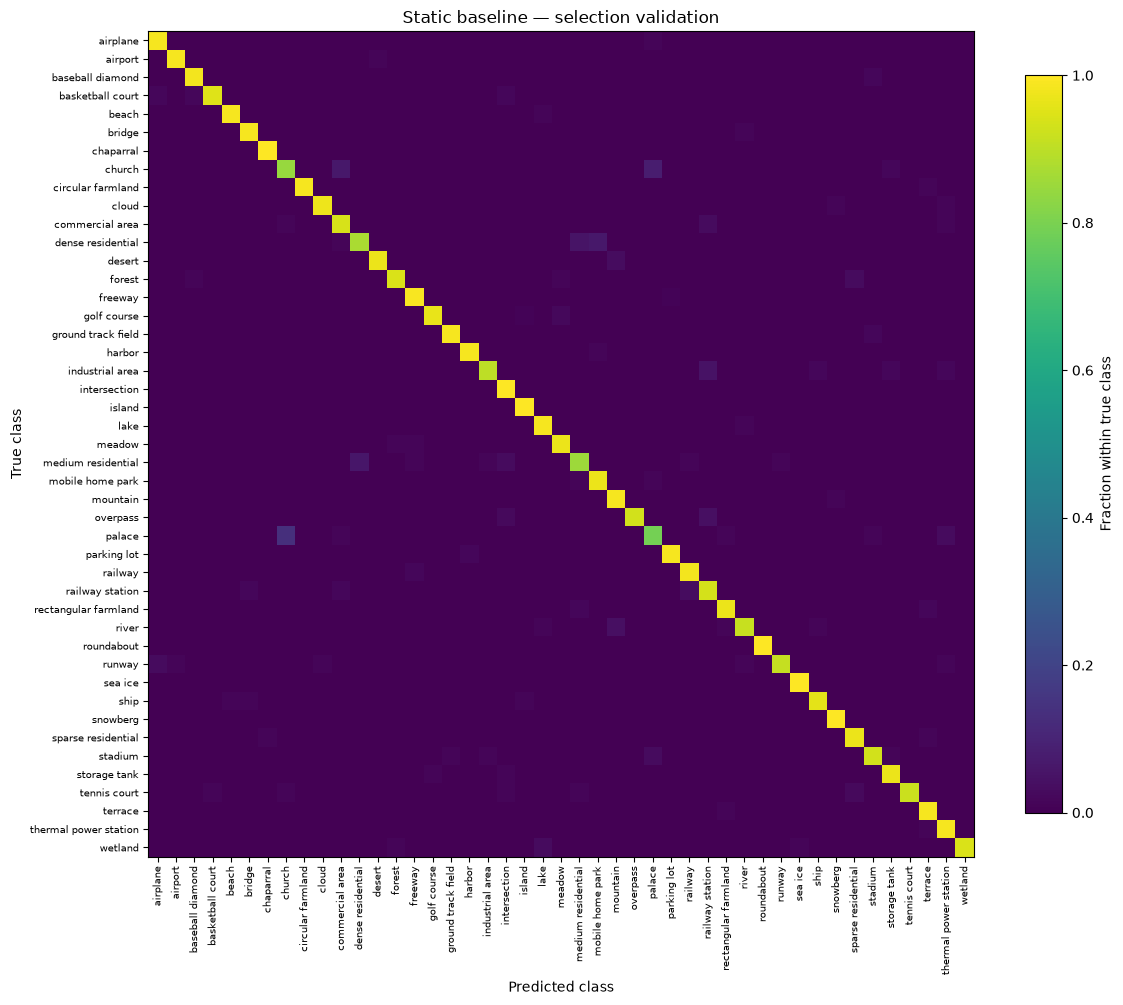

In [14]:
# visualising the row-normalised confusion matrix
row_confusion = np.divide(confusion, support[:, None],
                          out=np.zeros_like(confusion, dtype=float), where=support[:, None] > 0)
fig, ax = plt.subplots(figsize=(12, 11))
image = ax.imshow(row_confusion, vmin=0, vmax=1, interpolation="nearest")
labels_for_plot = [name.replace("_", " ") for name in class_names]
ax.set_xticks(range(NUM_CLASSES), labels_for_plot, rotation=90, fontsize=7)
ax.set_yticks(range(NUM_CLASSES), labels_for_plot, fontsize=7)
ax.set(xlabel="Predicted class", ylabel="True class", title="Static baseline — selection validation")
fig.colorbar(image, ax=ax, shrink=0.75, label="Fraction within true class")
fig.tight_layout()
fig.savefig(FIGURES / "baseline_confusion.pdf")
plt.show()


In [17]:
# identifying the five lowest-accuracy classes
hardest = per_class.nsmallest(5, "recall_pct").copy()
hardest["recall_pct"] = hardest["recall_pct"].round(2)

print("Five lowest-accuracy classes")
display(hardest.rename(columns={
    "class": "True class",
    "count": "Images",
    "recall_pct": "Accuracy (%)",
}).reset_index(drop=True))


# identifying the ten most frequent classification errors
errors = confusion.copy()
np.fill_diagonal(errors, 0)

rows, cols = np.where(errors > 0)

confusions = pd.DataFrame({
    "True class": [class_names[i] for i in rows],
    "Predicted as": [class_names[j] for j in cols],
    "Errors": errors[rows, cols],
    "Error rate (%)": (100 * errors[rows, cols] / support[rows]).round(2),
})

print("Ten most frequent misclassifications")
display(
    confusions.sort_values("Errors", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

Five lowest-accuracy classes


,True class,Images,Accuracy (%)
0,palace,67,79.10
1,church,64,84.38
2,medium_residential,68,85.29
3,dense_residential,78,87.18
4,industrial_area,60,90.00


Ten most frequent misclassifications


,True class,Predicted as,Errors,Error rate (%)
0,palace,church,9,13.43
1,church,palace,5,7.81
2,dense_residential,mobile_home_park,5,6.41
3,church,commercial_area,4,6.25
4,medium_residential,dense_residential,4,5.88
5,dense_residential,medium_residential,4,5.13
6,river,mountain,3,4.29
7,industrial_area,railway_station,3,5.00
8,overpass,railway_station,3,4.00
9,medium_residential,intersection,2,2.94


This motivates our hypothesis that images with clearly distinguishable features may require fewer transformer blocks (candidates for early exits), while visually ambiguous or more complex (i.e. visually confusing to the model) images may benefit from deeper processing.

### Batch-one inference latency

Latency is measured with an already-loaded model and an input tensor already on the device. The default reference is **CPU, FP32, one thread, batch size one**, even if fine-tuning occurred on an accelerator. This provides a consistent local reference and does **not** represent measured latency on an embedded edge device.

Each run records median and p95 model-forward latency after warm-up. Image decoding, preprocessing, model loading, transfers, queueing, and network communication are excluded. Lower FLOPs do not imply proportional energy or latency savings [C2, pp. 53–59].


In [15]:
# measuring real model-forward latency and saving the baseline summary
@torch.inference_mode()
def benchmark(network, example):
    device = select_device(BENCHMARK_DEVICE)
    original_threads = torch.get_num_threads()
    try:
        if device.type == "cpu":
            torch.set_num_threads(BENCHMARK_THREADS)
        measured = copy.deepcopy(network).to(device).float().eval()
        x = example[:1].to(device).float()
        for _ in range(BENCHMARK_WARMUP):
            measured(x)
        sync(device)
        times = []
        for _ in range(BENCHMARK_REPEATS):
            sync(device)
            t0 = time.perf_counter_ns()
            measured(x)
            sync(device)
            times.append((time.perf_counter_ns() - t0) / 1e6)
        return {"device": str(device), "precision": "float32", "batch_size": 1,
                "threads": BENCHMARK_THREADS if device.type == "cpu" else None,
                "median_ms": float(np.median(times)), "p95_ms": float(np.percentile(times, 95)),
                "warmup": BENCHMARK_WARMUP, "repeats": BENCHMARK_REPEATS,
                "timings_ms": times}
    finally:
        torch.set_num_threads(original_threads)


latency = benchmark(model, select_dataset[0][0].unsqueeze(0))
(RUN_DIR / "latency.json").write_text(json.dumps(latency, indent=2))
summary = {
    "model": MODEL_NAME, "run_mode": RUN_MODE, "validation_partition": "val_select",
    "selected_epoch": best["epoch"], "accuracy_pct": val_metrics["val_accuracy_pct"],
    "cross_entropy": val_metrics["val_loss"], "macro_recall_pct": float(100 * recall.mean()),
    "parameters": flops_profile["parameters"],
    "gflops_per_image": flops_profile["gflops_per_image"],
    "flops_convention": FLOPS_CONVENTION["version"],
    "latency_device": latency["device"], "median_ms": latency["median_ms"],
    "p95_ms": latency["p95_ms"], "checkpoint_sha256": file_sha256(BEST_PATH),
    "test_evaluated": False,
}
(RUN_DIR / "baseline_summary.json").write_text(json.dumps(summary, indent=2))
pd.DataFrame([summary]).to_csv(RUN_DIR / "baseline_summary.csv", index=False)
display(pd.Series(summary, name="baseline").to_frame())


,baseline
model,deit_tiny_patch16_224.fb_in1k
run_mode,full
validation_partition,val_select
selected_epoch,24
accuracy_pct,95.809525
cross_entropy,0.266806
macro_recall_pct,95.757013
parameters,5533101
gflops_per_image,1.274294
flops_convention,fvcore_fma1_scalar_v1


## 1F — Preserving the static reference


When we agree that our baseline is ready, setting `FREEZE_BASELINE = True` preserves its checkpoint and associated metadata in `runs/references/`. After approval, the adaptive model will be initialised from a separate copy, while this reference remains unchanged.

The Pareto frontier will be computed only after the adaptive architecture and stopping policy have been selected on validation data. Both systems must eventually be evaluated on the same untouched **test** partition.


In [16]:
# approving the fixed static baseline only after reviewing the results
FREEZE_BASELINE = False
REFERENCE_DIR = OUTPUT_DIR / "references" / "static_deit_tiny"

if FREEZE_BASELINE:
    if RUN_MODE != "full" or len(history) != TOTAL_EPOCHS:
        raise RuntimeError("A completed full run is required before approving the baseline.")
    reference_path = REFERENCE_DIR / "baseline_reference.pt"
    source_hash = file_sha256(BEST_PATH)
    if source_hash != summary["checkpoint_sha256"]:
        raise RuntimeError("Checkpoint changed after evaluation. Rerun Part E.")
    if REFERENCE_DIR.exists() and not reference_path.exists():
        raise RuntimeError("An incomplete reference directory exists. Inspect it before continuing.")
    if reference_path.exists():
        if not (REFERENCE_DIR / "reference.json").is_file():
            raise RuntimeError("Reference metadata is missing. Inspect the reference directory.")
        if file_sha256(reference_path) != source_hash:
            raise RuntimeError("A different static reference already exists. Do not overwrite it.")
        print("This checkpoint is already the approved reference.")
    else:
        REFERENCE_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(BEST_PATH, reference_path)
        shutil.copy2(manifest_path, REFERENCE_DIR / "split_manifest.csv")
        shutil.copy2(RUN_DIR / "class_to_idx.json", REFERENCE_DIR / "class_to_idx.json")
        (REFERENCE_DIR / "reference.json").write_text(json.dumps({
            "source_run": RUN_NAME, "sha256": source_hash,
            "selected_epoch": best["epoch"], "validation_summary": summary,
            "environment": environment,
        }, indent=2))
        print("Approved static baseline:", reference_path)
else:
    print("Baseline saved for review; formal approval remains pending.")


Baseline saved for review; formal approval remains pending.


### Files produced by each experiment

```text
runs/<RUN_NAME>/
├── run_config.json           # training choices and split hash
├── environment.json          # first-run software/hardware record
├── split_manifest.csv        # published splits plus reserved validation partition
├── class_to_idx.json         # fixed class-to-index mapping
├── best.pt                   # best selected model, future distillation teacher
├── last.pt                   # model + optimizer state, for resuming
├── history.csv               # loss and accuracy per epoch
├── flops.json                # consistent FLOPs convention and operator counts
├── latency.json              # measured forward-call latency
├── baseline_summary.csv      # selected-validation measurements
├── validation_per_class.csv
├── validation_predictions.csv
└── figures/
    ├── baseline_loss.pdf
    ├── baseline_accuracy.pdf
    └── baseline_confusion.pdf
```


### Part 1 - conclusion:

The static DeiT-Tiny vision transformer baseline achieved 95.81% accuracy on the model-selection validation partition. The row-normalised confusion matrix exhibits a strong diagonal across most scene categories, indicating reliable classification performance. Remaining errors are distributed across a subset of classes, suggesting we should take a closer look at class-level performance and visually confusable categories. 

Error analysis revealed systematic confusion between visually related scene categories, particularly palace and church, as well as residential categories of differing density. The five lowest-recall classes accounted for 50 of the 132 misclassifications. These findings motivate investigating whether intermediate transformer representations provide sufficiently reliable predictions for selective early exiting, while deeper processing is reserved for images that may benefit from it.

These results establish the predictive performance of thestatic, full-depth vision transformer model against which adaptive inference will then be evaluated.

## Sources

**[C1]** *Big Data Project — Adaptive Inference for Edge AI*, Big Data at the Edge, course project brief, §§5–6 and 9. Used for the assignment requirements and baseline/evaluation protocol.

**[C2]** Dolly Sapra, *Pruning Basics*, Big Data at the Edge, 7 September 2026, pp. 53–59. Cost, runtime, memory, and energy measurement distinctions.

**[R1]** G. Cheng, J. Han, and X. Lu (2017). *Remote Sensing Image Scene Classification: Benchmark and State of the Art.* Proceedings of the IEEE, 105(10), 1865–1883. [DOI](https://doi.org/10.1109/JPROC.2017.2675998).

**[R2]** TorchGeo, [RESISC45 dataset loader](https://github.com/torchgeo/torchgeo/blob/main/torchgeo/datasets/resisc45.py), consulted October 2026. Contains the pinned download revision and archive checksum; TorchGeo is not required for execution.

**[R3]** M. Neumann et al. (2019). *In-domain representation learning for remote sensing.* [Google Research splits](https://github.com/google-research/google-research/tree/master/remote_sensing_representations).

**[R4]** PyTorch, [version and installation guidance](https://pytorch.org/get-started/previous-versions/).

**[R5]** PyTorch, [reproducibility notes](https://docs.pytorch.org/docs/stable/notes/randomness.html).

**[R6]** PyTorch, [MPS backend](https://docs.pytorch.org/docs/stable/notes/mps.html).

**[R7]** PyTorch, [mixed-precision guidance](https://docs.pytorch.org/docs/stable/notes/amp_examples.html).

**[R8]** H. Touvron et al. (2021). *Training data-efficient image transformers & distillation through attention*. ICML. [Paper](https://proceedings.mlr.press/v139/touvron21a.html).

**[R9]** [timm DeiT-Tiny checkpoint](https://huggingface.co/timm/deit_tiny_patch16_224.fb_in1k).

**[R10]** [fvcore FLOP-counting conventions](https://detectron2.readthedocs.io/en/stable/modules/fvcore.html).

The implementation is published under Apache-2.0. Dataset images, pretrained weights, and external material retain their separate license terms defined by the dataset publishers/creators. Commercial redistribution is not allowed.
